# Survival Robustness

Kaplan-Meier summaries, log-rank tests, Cox diagnostics (with PH tests and buyer-clustered robust
SEs), AFT comparisons, prediction calibration, and temporal validation - across every linkage
variant that has a survival dataset. Interactive version of `scripts/run_survival_analysis.py`;
**running this notebook regenerates all `survival_*` tables** under `reports/tables/`.

Variant survival datasets come from notebook 08 (balanced), 14 (window sensitivity) and 15
(duration-leakage designs) - run those first if the files are missing.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullAFTFitter, LogNormalAFTFitter
from lifelines.statistics import logrank_test, proportional_hazard_test
from lifelines.utils import concordance_index, restricted_mean_survival_time
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
P = PROJECT_ROOT / "data" / "processed"
T = PROJECT_ROOT / "reports" / "tables"
T.mkdir(parents=True, exist_ok=True)

VARIANTS = ["balanced", "broad", "strict", "no_temporal_score_reference_pool",
            "forward_24m_no_duration", "window_9m", "window_12m", "window_18m"]


def load(v):
    path = P / f"boamp_survival_m0_{v}.csv"
    if not path.exists():
        return None
    return pd.read_csv(path, parse_dates=["publication_date", "start_date",
                                          "estimated_end_date", "study_end_date"], low_memory=False)

## Model prep and fitting helpers

`prep` builds the covariate frame (log-duration, imputation flag, CPV-division and buyer-key-type
dummies). `fit_cox` fits a buyer-clustered robust Cox model (penalizer 0.01) and writes per-variant
PH diagnostics; the quadratic variant adds `log_duration**2` as a functional-form check.

In [2]:
def prep(df):
    x = df[["time_to_event_or_censor_months", "event", "declared_duration_months", "dur_was_imputed",
            "buyer_key", "buyer_key_type", "cpv_division", "publication_date"]].copy()
    x = x[x.time_to_event_or_censor_months > 0].dropna(subset=["declared_duration_months"])
    x["log_duration"] = np.log1p(x.declared_duration_months)
    x["duration_sq"] = x.log_duration ** 2
    x["dur_was_imputed"] = x.dur_was_imputed.astype(int)
    x["start_year"] = x.publication_date.dt.year
    x["cpv_division"] = x.cpv_division.fillna("MISSING").astype(str)
    x["buyer_key_type"] = x.buyer_key_type.fillna("MISSING").astype(str)
    return pd.get_dummies(x, columns=["cpv_division", "buyer_key_type"], drop_first=True)


def fit_cox(df, v, quadratic=False):
    x = prep(df)
    base = ["time_to_event_or_censor_months", "event", "buyer_key", "log_duration", "dur_was_imputed"]
    cols = base + (["duration_sq"] if quadratic else []) + [
        c for c in x.columns if c.startswith("cpv_division_") or c.startswith("buyer_key_type_")]
    x = x[cols].copy()
    rows = []
    try:
        c = CoxPHFitter(penalizer=0.01)
        c.fit(x, duration_col="time_to_event_or_censor_months", event_col="event",
              cluster_col="buyer_key", robust=True)
        for term, r in c.summary.iterrows():
            rows.append(dict(variant=v, model="cox_clustered_quadratic" if quadratic else "cox_clustered",
                             term=term, coef=r.coef, exp_coef=r["exp(coef)"], p=r.p,
                             ci_lower=r["exp(coef) lower 95%"], ci_upper=r["exp(coef) upper 95%"]))
        ph = proportional_hazard_test(c, x, duration_col="time_to_event_or_censor_months", event_col="event")
        phdf = ph.summary.reset_index().rename(columns={"index": "term"})
        phdf.insert(0, "variant", v)
        phdf.to_csv(T / f"survival_ph_diagnostics_{v}.csv", index=False)
        return rows, c, x
    except Exception as e:
        rows.append(dict(variant=v, model="cox_clustered_quadratic" if quadratic else "cox_clustered",
                         term="ERROR", coef=np.nan, exp_coef=np.nan, p=np.nan,
                         ci_lower=np.nan, ci_upper=np.nan, error=str(e)))
        return rows, None, x


def aft(df, v):
    x = prep(df).drop(columns=["buyer_key", "publication_date"], errors="ignore")
    rows = []
    for cls, name in [(WeibullAFTFitter, "weibull_aft"), (LogNormalAFTFitter, "lognormal_aft")]:
        try:
            m = cls(penalizer=0.01)
            m.fit(x, duration_col="time_to_event_or_censor_months", event_col="event")
            rows.append(dict(variant=v, model=name, AIC=m.AIC_, log_likelihood=m.log_likelihood_,
                             concordance_index=getattr(m, "concordance_index_", np.nan)))
        except Exception as e:
            rows.append(dict(variant=v, model=name, AIC=np.nan, log_likelihood=np.nan,
                             concordance_index=np.nan, error=str(e)))
    return rows


def prediction_calibration(df, v, c, x):
    if c is None:
        return []
    rows = []
    for h in [12, 24]:
        try:
            risk = 1 - c.predict_survival_function(x, times=[h]).T.iloc[:, 0].to_numpy()
            tmp = df.loc[x.index].copy()
            tmp["pred_risk"] = risk
            tmp["observed_by_horizon"] = ((tmp.event == 1) & (tmp.time_to_event_or_censor_months <= h)).astype(int)
            tmp["risk_group"] = pd.qcut(pd.Series(risk).rank(method="first"), 5, labels=False) + 1
            for g, z in tmp.groupby("risk_group"):
                rows.append(dict(variant=v, horizon_months=h, risk_group=int(g), n=len(z),
                                 mean_predicted_risk=z.pred_risk.mean(),
                                 observed_event_rate=z.observed_by_horizon.mean(),
                                 brier_score=np.mean((z.observed_by_horizon - z.pred_risk) ** 2)))
        except Exception as e:
            rows.append(dict(variant=v, horizon_months=h, risk_group=-1, n=0,
                             mean_predicted_risk=np.nan, observed_event_rate=np.nan,
                             brier_score=np.nan, error=str(e)))
    return rows

## Fit everything, per variant

In [3]:
km_rows = []; logrank_rows = []; cox_rows = []; aft_rows = []
pred_rows = []; complexity = []; functional = []; validation = []
dfs = {}

for v in VARIANTS:
    df = load(v)
    if df is None:
        print(f"{v}: no survival dataset, skipped")
        continue
    dfs[v] = df
    print(f"{v}: n={len(df)}, events={int(df.event.sum())}")

    km = KaplanMeierFitter()
    km.fit(df.time_to_event_or_censor_months, df.event, label=v)
    km_rows.append(dict(variant=v, n=len(df), events=int(df.event.sum()),
                        censoring_rate=1 - df.event.mean(),
                        median_survival_months=km.median_survival_time_,
                        survival_at_12m=float(km.survival_function_at_times(12).iloc[0]),
                        survival_at_24m=float(km.survival_function_at_times(24).iloc[0]),
                        rmst_60m=float(restricted_mean_survival_time(km, t=60))))
    complexity.append(dict(variant=v, events=int(df.event.sum()), n_sources=len(df),
                           n_buyers=df.buyer_key.nunique(),
                           candidate_parameters_estimated="log_duration + imputation + CPV dummies + buyer_key_type dummies",
                           approx_events_per_parameter=df.event.sum() / max(1, (2 + df.cpv_division.nunique() + df.buyer_key_type.nunique() - 2))))

    for div, g in df.groupby("cpv_division", dropna=False):
        if len(g) > 10:
            k = KaplanMeierFitter()
            k.fit(g.time_to_event_or_censor_months, g.event)
            km_rows.append(dict(variant=v + "__cpv", cpv_division=div, n=len(g), events=int(g.event.sum()),
                                censoring_rate=1 - g.event.mean(),
                                median_survival_months=k.median_survival_time_,
                                survival_at_12m=float(k.survival_function_at_times(12).iloc[0]),
                                survival_at_24m=float(k.survival_function_at_times(24).iloc[0]),
                                rmst_60m=float(restricted_mean_survival_time(k, t=60))))

    divs = [g for _, g in df[df.cpv_division.isin(["32", "35", "48", "72"])].groupby("cpv_division") if g.event.sum() > 0]
    for i in range(len(divs)):
        for j in range(i + 1, len(divs)):
            a, b = divs[i], divs[j]
            res = logrank_test(a.time_to_event_or_censor_months, b.time_to_event_or_censor_months,
                               event_observed_A=a.event, event_observed_B=b.event)
            logrank_rows.append(dict(variant=v, group_a=str(a.cpv_division.iloc[0]),
                                     group_b=str(b.cpv_division.iloc[0]),
                                     test_statistic=res.test_statistic, p=res.p_value))

    rows, c, x = fit_cox(df, v, False)
    cox_rows += rows
    qrows, _, _ = fit_cox(df, v, True)
    functional += [r for r in qrows if r.get("term") in ["log_duration", "duration_sq", "ERROR"]]
    aft_rows += aft(df, v)
    pred_rows += prediction_calibration(df, v, c, x)

    # Temporal validation: train on <=2021, score on >2021.
    try:
        train = df[df.publication_date.dt.year <= 2021]
        test = df[df.publication_date.dt.year > 2021]
        tr_rows, c2, xtr = fit_cox(train, v + "_train_to_2021", False)
        if c2 is not None and len(test) > 0:
            xt = prep(test)
            xt = xt.reindex(columns=xtr.columns, fill_value=0)
            score = -c2.predict_partial_hazard(xt).to_numpy().ravel()
            validation.append(dict(variant=v, train_n=len(train), train_events=int(train.event.sum()),
                                   test_n=len(test), test_events=int(test.event.sum()),
                                   test_c_index=concordance_index(
                                       test.loc[xt.index, "time_to_event_or_censor_months"], score,
                                       test.loc[xt.index, "event"])))
        elif c2 is None:
            # The train-only design is sparse and high-dimensional; when the fit
            # does not converge, record the deferral instead of dropping the row.
            validation.append(dict(variant=v, train_n=len(train), train_events=int(train.event.sum()),
                                   test_n=len(test), test_events=int(test.event.sum()),
                                   test_c_index=np.nan,
                                   error="deferred: sparse high-dimensional Cox design did not yield a stable temporal-validation fit in this audit run"))
    except Exception as e:
        validation.append(dict(variant=v, error=str(e)))

balanced: n=3159, events=618


/home/senghakrou/survival-analysis/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column cpv_division_22.0 have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['event'].astype(bool)
>>> print(df.loc[events, 'cpv_division_22.0'].var())
>>> print(df.loc[~events, 'cpv_division_22.0'].var())

A very low variance means that the column cpv_division_22.0 completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/home/senghakrou/survival-analysis/.venv/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation

/home/senghakrou/survival-analysis/.venv/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1530: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 0.0.
  inv_h_dot_g_T = spsolve(-h, g, assume_a="pos", check_finite=False)


broad: n=3159, events=927


/home/senghakrou/survival-analysis/.venv/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1530: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 0.0.
  inv_h_dot_g_T = spsolve(-h, g, assume_a="pos", check_finite=False)


...

/home/senghakrou/survival-analysis/.venv/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1530: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 0.0.
  inv_h_dot_g_T = spsolve(-h, g, assume_a="pos", check_finite=False)


window_12m: n=3159, events=754


/home/senghakrou/survival-analysis/.venv/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1530: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 0.0.
  inv_h_dot_g_T = spsolve(-h, g, assume_a="pos", check_finite=False)


window_18m: n=3159, events=834


/home/senghakrou/survival-analysis/.venv/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1530: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 0.0.
  inv_h_dot_g_T = spsolve(-h, g, assume_a="pos", check_finite=False)


## Write the `survival_*` tables

In [4]:
km_summary_df = pd.DataFrame(km_rows)
km_summary_df.to_csv(T / "survival_km_summary.csv", index=False)
pd.DataFrame(logrank_rows).to_csv(T / "survival_logrank_tests.csv", index=False)
cox_models_df = pd.DataFrame(cox_rows)
cox_models_df.to_csv(T / "survival_cox_models.csv", index=False)
aft_df = pd.DataFrame(aft_rows)
aft_df.to_csv(T / "survival_aft_models.csv", index=False)
pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv(T / "survival_predictions_12_24m.csv", index=False)
pd.DataFrame(complexity).to_csv(T / "survival_event_complexity.csv", index=False)
functional_df = pd.DataFrame(functional)
functional_df.to_csv(T / "survival_functional_form.csv", index=False)
validation_df = pd.DataFrame(validation, columns=["variant", "train_n", "train_events", "test_n",
                                                  "test_events", "test_c_index", "error"])
validation_df.to_csv(T / "survival_temporal_validation.csv", index=False)
print("tables written to", T)

tables written to /home/senghakrou/survival-analysis/reports/tables


## KM / RMST summary and key model results

In [5]:
display(km_summary_df[km_summary_df.variant.isin(VARIANTS)]
        [["variant", "n", "events", "censoring_rate", "median_survival_months",
          "survival_at_12m", "survival_at_24m", "rmst_60m"]].round(3))

,variant,n,events,censoring_rate,median_survival_months,survival_at_12m,survival_at_24m,rmst_60m
0,balanced,3159,618,0.804,inf,0.924,0.914,53.513
15,broad,3159,927,0.707,inf,0.901,0.880,50.467
30,strict,3159,309,0.902,inf,0.964,0.960,56.879
45,no_temporal_score_reference_pool,3159,618,0.804,inf,0.930,0.921,53.768
60,forward_24m_no_duration,3159,1105,0.650,inf,0.737,0.637,41.070
75,window_9m,3159,693,0.781,inf,0.919,0.905,52.801
90,window_12m,3159,754,0.761,inf,0.916,0.899,52.222
105,window_18m,3159,834,0.736,inf,0.910,0.890,51.361


In [6]:
dur_effect = cox_models_df[cox_models_df.term == "log_duration"][
    ["variant", "exp_coef", "ci_lower", "ci_upper", "p"]].round(4)
display(dur_effect)
display(aft_df.round(2))
display(validation_df.round(3))

,variant,exp_coef,ci_lower,ci_upper,p
0,balanced,0.9231,0.7710,1.1052,0.3839
34,broad,1.0242,0.8413,1.2469,0.8117
68,strict,0.9540,0.7983,1.1401,0.6043
102,no_temporal_score_reference_pool,0.9533,0.7937,1.1448,0.6084
136,forward_24m_no_duration,1.1607,1.0113,1.3322,0.0340
170,window_9m,0.8492,0.7150,1.0086,0.0625
204,window_12m,0.9630,0.7969,1.1637,0.6962
238,window_18m,0.9801,0.8139,1.1803,0.8321


,variant,model,AIC,log_likelihood,concordance_index
0,balanced,weibull_aft,8059.77,-3990.88,0.71
1,balanced,lognormal_aft,7948.96,-3935.48,0.72
2,broad,weibull_aft,11349.90,-5635.95,0.69
3,broad,lognormal_aft,11118.38,-5520.19,0.71
4,strict,weibull_aft,4526.68,-2224.34,0.71
5,strict,lognormal_aft,4533.68,-2227.84,0.72
6,no_temporal_score_reference_pool,weibull_aft,8106.84,-4014.42,0.69
7,no_temporal_score_reference_pool,lognormal_aft,8032.12,-3977.06,0.70
8,forward_24m_no_duration,weibull_aft,11479.33,-5700.67,0.60
9,forward_24m_no_duration,lognormal_aft,11329.04,-5625.52,0.61


,variant,train_n,train_events,test_n,test_events,test_c_index,error
0,balanced,2082,516,1077,102,NaN,deferred: sparse high-dimensional Cox design d...
1,broad,2082,782,1077,145,NaN,deferred: sparse high-dimensional Cox design d...
2,strict,2082,259,1077,50,NaN,deferred: sparse high-dimensional Cox design d...
3,no_temporal_score_reference_pool,2082,506,1077,112,NaN,deferred: sparse high-dimensional Cox design d...
4,forward_24m_no_duration,2082,805,1077,300,NaN,deferred: sparse high-dimensional Cox design d...
5,window_9m,2082,572,1077,121,NaN,deferred: sparse high-dimensional Cox design d...
6,window_12m,2082,617,1077,137,NaN,deferred: sparse high-dimensional Cox design d...
7,window_18m,2082,678,1077,156,NaN,deferred: sparse high-dimensional Cox design d...


## Kaplan-Meier curves — threshold variants

In [7]:
import matplotlib.pyplot as plt

# Project palette (light mode) - identical to scripts/make_figures.py.
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
CAT = {
    "blue": "#2a78d6", "aqua": "#1baf7a", "yellow": "#eda100", "green": "#008300",
    "violet": "#4a3aa7", "red": "#e34948", "magenta": "#e87ba4", "orange": "#eb6834",
}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_PRIMARY, "text.color": INK_PRIMARY,
    "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY,
    "axes.grid": True, "grid.color": GRIDLINE, "grid.linewidth": 0.7,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "sans-serif", "font.size": 10.5,
    "axes.titlesize": 12, "axes.titleweight": "bold", "figure.dpi": 120,
})
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_and_show(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.pdf")
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200)
    plt.show()

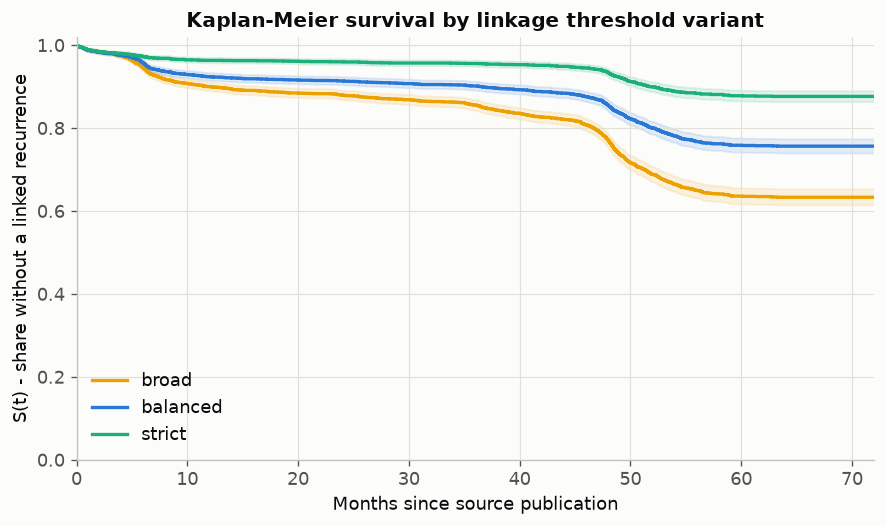

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for v, color in [("broad", CAT["yellow"]), ("balanced", CAT["blue"]), ("strict", CAT["aqua"])]:
    if v not in dfs:
        continue
    km = KaplanMeierFitter()
    km.fit(dfs[v].time_to_event_or_censor_months, dfs[v].event, label=v)
    km.plot_survival_function(ax=ax, color=color, linewidth=2, ci_alpha=0.12)
ax.set_xlim(0, 72)
ax.set_ylim(0, 1.02)
ax.set_title("Kaplan-Meier survival by linkage threshold variant")
ax.set_xlabel("Months since source publication")
ax.set_ylabel("S(t) - share without a linked recurrence")
ax.legend(frameon=False)
save_and_show(fig, "nb16_km_threshold_variants")

## Prediction calibration (balanced variant)

Mean predicted 12/24-month risk vs the observed event rate per predicted-risk quintile; points on
the diagonal are perfectly calibrated.

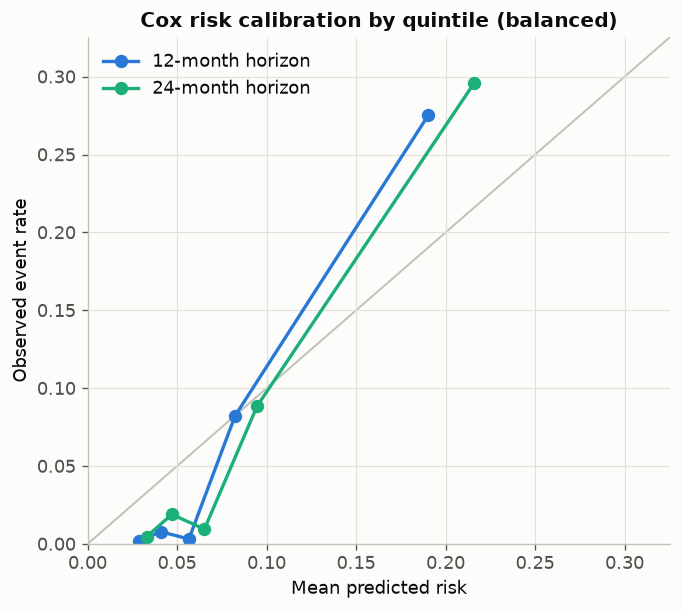

In [9]:
cal = pred_df[(pred_df.variant == "balanced") & (pred_df.risk_group > 0)]
fig, ax = plt.subplots(figsize=(5.8, 5.2))
for h, color in [(12, CAT["blue"]), (24, CAT["aqua"])]:
    sub = cal[cal.horizon_months == h]
    ax.plot(sub.mean_predicted_risk, sub.observed_event_rate, marker="o", linewidth=2,
            markersize=7, color=color, label=f"{h}-month horizon")
lim = max(cal.mean_predicted_risk.max(), cal.observed_event_rate.max()) * 1.1 if len(cal) else 1
ax.plot([0, lim], [0, lim], color=BASELINE, linewidth=1.2, zorder=0)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_title("Cox risk calibration by quintile (balanced)")
ax.set_xlabel("Mean predicted risk")
ax.set_ylabel("Observed event rate")
ax.legend(frameon=False)
save_and_show(fig, "nb16_calibration_balanced")